In [ ]:
# Instalación de librerías necesarias
!pip install arxiv pandas matplotlib PyMuPDF

In [ ]:
import arxiv
import pandas as pd
import time
import random
import os
from datetime import datetime

# Archivo donde guardaremos todo
FILE_NAME = "progreso_arxiv_montecarlo.csv"

clanes = {
    "MC_Hull_White": 'all:"Monte Carlo" AND (all:"Hull-White" OR all:"Interest Rate")',
    "MC_Riesgo": 'all:"Monte Carlo" AND (all:"CVA" OR all:"Counterparty" OR all:"Credit Risk")',
    "MC_Tech": 'all:"Monte Carlo" AND (all:"GPU" OR all:"Parallel" OR all:"Machine Learning")'
}

def guardar_progreso(df_nuevo):
    """Guarda o actualiza el archivo CSV con los nuevos datos."""
    if os.path.exists(FILE_NAME):
        df_antiguo = pd.read_csv(FILE_NAME, index_col=0)
        # Combinamos y sumamos los conteos por año
        df_final = df_antiguo.add(df_nuevo, fill_value=0)
    else:
        df_final = df_nuevo
    
    df_final.to_csv(FILE_NAME)
    print(f"[{datetime.now().strftime('%H:%M:%S')}] Disco actualizado: {FILE_NAME}")

def fetch_incremental():
    client = arxiv.Client(page_size=50, delay_seconds=5, num_retries=10)
    
    for nombre, query in clanes.items():
        print(f"\n--- Iniciando Clan: {nombre} ---")
        years = []
        search = arxiv.Search(query=query, max_results=1000)
        
        try:
            results_generator = client.results(search)
            contador_sesion = 0
            
            while True:
                try:
                    result = next(results_generator)
                    years.append(result.published.year)
                    contador_sesion += 1
                    
                    # Cada 50 resultados guardamos en disco para no perder nada
                    if contador_sesion % 50 == 0:
                        # Convertimos lo que llevamos de este clan a un DataFrame temporal
                        df_temp = pd.DataFrame({nombre: pd.Series(years).value_counts()}).fillna(0)
                        guardar_progreso(df_temp)
                        years = [] # Limpiamos la lista para no duplicar en el próximo guardado
                        
                        wait = random.uniform(15, 25)
                        print(f"Pausa de seguridad: {wait:.2f}s")
                        time.sleep(wait)
                        
                except StopIteration:
                    # Guardar el resto que quede en la lista 'years'
                    if years:
                        df_temp = pd.DataFrame({nombre: pd.Series(years).value_counts()}).fillna(0)
                        guardar_progreso(df_temp)
                    break
                except Exception as e:
                    print(f"Error de conexión: {e}. Esperando 5 min...")
                    time.sleep(300)
                    continue
            
            print(f"Clan {nombre} finalizado.")
            time.sleep(120) # Descanso entre clanes

        except Exception as e:
            print(f"Fallo en {nombre}: {e}")

# --- EJECUCIÓN ---
fetch_incremental()

In [ ]:
import arxiv
import pandas as pd
import time
import random
import os
from datetime import datetime

FILE_NAME = "datos_maestros_arxiv_finanzas.csv"

# CLANES REFINADOS: Los "Fósiles" de la Historia Financiera
clanes = {
    "Era_Exotica_Pricing": 'all:"Monte Carlo" AND (all:"Bermudan" OR all:"Longstaff-Schwartz" OR all:"Path-dependent")',
    "Era_Riesgo_Regulacion": 'all:"Monte Carlo" AND (all:"CVA" OR all:"XVA" OR all:"Counterparty Risk")',
    "Era_IA_Eficiencia": 'all:"Monte Carlo" AND (all:"Deep Learning" OR all:"Neural Network" OR all:"AAD")'
}

def fetch_master_data():
    client = arxiv.Client(page_size=100, delay_seconds=10, num_retries=5)
    
    for nombre, query in clanes.items():
        print(f"\n[{datetime.now().strftime('%H:%M:%S')}] Investigando: {nombre}")
        years = []
        # Subimos a 2000 para capturar bien las colas históricas
        search = arxiv.Search(query=query, max_results=2000, sort_by=arxiv.SortCriterion.SubmittedDate)
        
        try:
            results_generator = client.results(search)
            count = 0
            for result in results_generator:
                years.append(result.published.year)
                count += 1
                if count % 100 == 0:
                    print(f"   > {count} papers procesados...")
            
            if years:
                df_temp = pd.DataFrame({nombre: pd.Series(years).value_counts()}).fillna(0)
                # Guardado incremental
                if os.path.exists(FILE_NAME):
                    df_old = pd.read_csv(FILE_NAME, index_col=0)
                    df_final = df_old.add(df_temp, fill_value=0)
                else:
                    df_final = df_temp
                df_final.to_csv(FILE_NAME)
            
            print(f"--- Fin del Clan {nombre} ---")
            time.sleep(120) # Descanso profundo entre clanes

        except Exception as e:
            print(f"Error en {nombre}: {e}")
            time.sleep(300)

fetch_master_data()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_arxiv_results(file_path="datos_maestros_arxiv_finanzas.csv"):
    try:
        # 1. Cargar datos
        # El archivo tiene los años como índice y los clanes como columnas
        df = pd.read_csv(file_path, index_col=0)
        
        # 2. Limpieza y Ordenación
        df.index = pd.to_numeric(df.index)
        df = df.sort_index()
        
        # Filtramos años coherentes (desde que nació arXiv hasta hoy)
        df = df[(df.index >= 1991) & (df.index <= 2024)]
        
        # 3. Suavizado (Media móvil de 2 años para ver tendencias claras)
        df_smooth = df.rolling(window=2, min_periods=1).mean()

        # 4. Configuración Estética
        plt.style.use('seaborn-v0_8-whitegrid') # Estilo limpio
        fig, ax = plt.subplots(figsize=(12, 7))
        
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Azul, Naranja, Verde
        
        # Dibujar áreas sombreadas para dar peso visual
        for i, column in enumerate(df_smooth.columns):
            ax.plot(df_smooth.index, df_smooth[column], label=column.replace('_', ' '), 
                    linewidth=3, color=colors[i])
            ax.fill_between(df_smooth.index, df_smooth[column], alpha=0.1, color=colors[i])

        # 5. Anotaciones de Contexto Histórico
        # Aquí es donde relacionas los datos con tu tesis
        eventos = {
            2008: "Crisis Lehman\n(Auge Riesgo)",
            2014: "Regulación\nFundamental Review",
            2020: "Pandemia\n(Volatilidad)"
        }
        
        for year, label in eventos.items():
            if year in df_smooth.index:
                ax.axvline(x=year, color='gray', linestyle='--', alpha=0.5)
                ax.text(year, ax.get_ylim()[1]*0.8, label, rotation=0, 
                        ha='center', fontsize=9, bbox=dict(facecolor='white', alpha=0.7))

        # 6. Etiquetas y Títulos
        ax.set_title("Evolución de Monte Carlo en la Literatura Financiera (arXiv)", fontsize=16, pad=20)
        ax.set_xlabel("Año de Publicación", fontsize=12)
        ax.set_ylabel("Volumen de Artículos (Suavizado)", fontsize=12)
        ax.legend(frameon=True, fontsize=11, loc='upper left')
        
        plt.tight_layout()
        plt.show()
        
    except FileNotFoundError:
        print("El archivo CSV aún no existe. Espera a que el script de descarga guarde los primeros datos.")
    except Exception as e:
        print(f"Error al procesar el gráfico: {e}")

# Ejecutar la representación
plot_arxiv_results()

In [ ]:
# Graficar la evolución
df.plot(kind='line', marker='', figsize=(12, 6))
plt.title('Evolución de Menciones en arXiv (Fundamentación Técnica)')
plt.xlabel('Año')
plt.ylabel('Número de Artículos')
plt.grid(True)
plt.show()

In [ ]:
!pip install ndjson

In [ ]:
import pandas as pd
import requests
import matplotlib.pyplot as plt

def get_refined_history():
    # Usamos términos que sabemos que existen y representan las eras
    # 'Options pricing' es el proxy de la llegada de Montecarlo
    # 'Value at Risk' es el proxy del uso masivo de simulación tras Basilea
    queries = [
        "Monte Carlo method", 
        "Options pricing", 
        "Hull-White", 
        "Value at Risk",
        "Derivative pricing"
    ]
    
    query_str = ",".join(queries)
    url = f"https://books.google.com/ngrams/json?content={query_str}&year_start=1970&year_end=2019&corpus=26&smoothing=3"
    
    response = requests.get(url)
    if response.status_code != 200:
        return print("Error de conexión con la API")
    
    data = response.json()
    
    plt.figure(figsize=(14, 7))
    for entry in data:
        # Normalizamos el nombre para que sea legible
        label = entry['ngram']
        plt.plot(range(1970, 2020), entry['timeseries'], label=label, linewidth=2.5)
    
    # Hitos de Historia Económica y Tecnológica
    eventos = {
        1973: "Black-Scholes / Fin Bretton Woods",
        1987: "Lunes Negro (Necesidad de Stress Test)",
        1994: "JP Morgan lanza RiskMetrics (VaR)",
        2008: "Crisis Financiera (Era XVA)"
    }
    
    for year, txt in eventos.items():
        plt.axvline(x=year, color='red', linestyle='--', alpha=0.3)
        plt.text(year, 0, txt, rotation=90, verticalalignment='bottom', fontsize=9)

    plt.title("Evolución de la Infraestructura Cuantitativa (1970-2019)")
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.2)
    plt.show()

get_refined_history()

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import time

def fetch_openalex_trend(query_filter):
    # Función genérica para extraer conteos por año
    url = f"https://api.openalex.org/works?search={query_filter}&group_by=publication_year&filter=publication_year:>1990"
    headers = {"User-Agent": "mailto:tu_correo@ejemplo.com"}
    response = requests.get(url, headers=headers)
    
    if response.status_code == 200:
        data = response.json()
        # Filtramos años futuros/incompletos
        return {int(g['key']): g['count'] for g in data.get('group_by', []) if int(g['key']) < 2026}
    return {}

print("Obteniendo el 'Baseline' (Total de publicaciones en Finanzas)...")
# El denominador: Todo lo que contenga la palabra "Finance"
baseline_counts = fetch_openalex_trend('"Finance"')
time.sleep(1)

# Nuestras categorías (Numeradores)
categorias = {
    "Riesgo Clásico (VaR/Pricing)": '("Monte Carlo") AND ("Value at Risk" OR "Option Pricing")',
    "Post-Crisis (XVA/CVA)": '("Monte Carlo") AND ("CVA" OR "XVA" OR "Counterparty Risk")',
    "Aceleración Tech (GPU/AAD)": '("Monte Carlo") AND ("GPU" OR "CUDA" OR "Adjoint Algorithmic Differentiation")'
}

print("Obteniendo datos específicos...")
resultados = {}
años_rango = range(1990, 2026)

for nombre, query in categorias.items():
    resultados[nombre] = fetch_openalex_trend(query)
    time.sleep(1)

# Construimos el DataFrame
df_absoluto = pd.DataFrame(index=años_rango)
df_relativo = pd.DataFrame(index=años_rango)

# Añadimos el baseline al dataframe
df_absoluto['Total_Finance'] = df_absoluto.index.map(baseline_counts).fillna(1) # fillna(1) para evitar dividir por cero

for nombre, datos in resultados.items():
    # 1. Guardamos el valor absoluto
    df_absoluto[nombre] = df_absoluto.index.map(datos).fillna(0)
    
    # 2. CALCULAMOS LA FRECUENCIA RELATIVA (El porcentaje)
    df_relativo[nombre] = (df_absoluto[nombre] / df_absoluto['Total_Finance']) * 100

# Graficamos los datos normalizados
plt.figure(figsize=(15, 8))

for col in df_relativo.columns:
    plt.plot(df_relativo.index, df_relativo[col], label=col, linewidth=2.5, marker='.')

plt.axvspan(2007, 2009, color='red', alpha=0.1, label='Crisis Financiera')

plt.title('Popularidad Relativa: Porcentaje de papers sobre el total de "Finanzas"', fontsize=16)
plt.ylabel('% del Total de Publicaciones Financieras')
plt.xlabel('Año')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

Extrayendo datos de OpenAlex...
Consultando: Baseline (Total Finance)
Consultando: Monte Carlo: VaR
Consultando: Monte Carlo: Expected Shortfall
Consultando: Contexto Regulatorio (FRTB/Basel)
Consultando: Eficiencia/GPU (Aceleración)


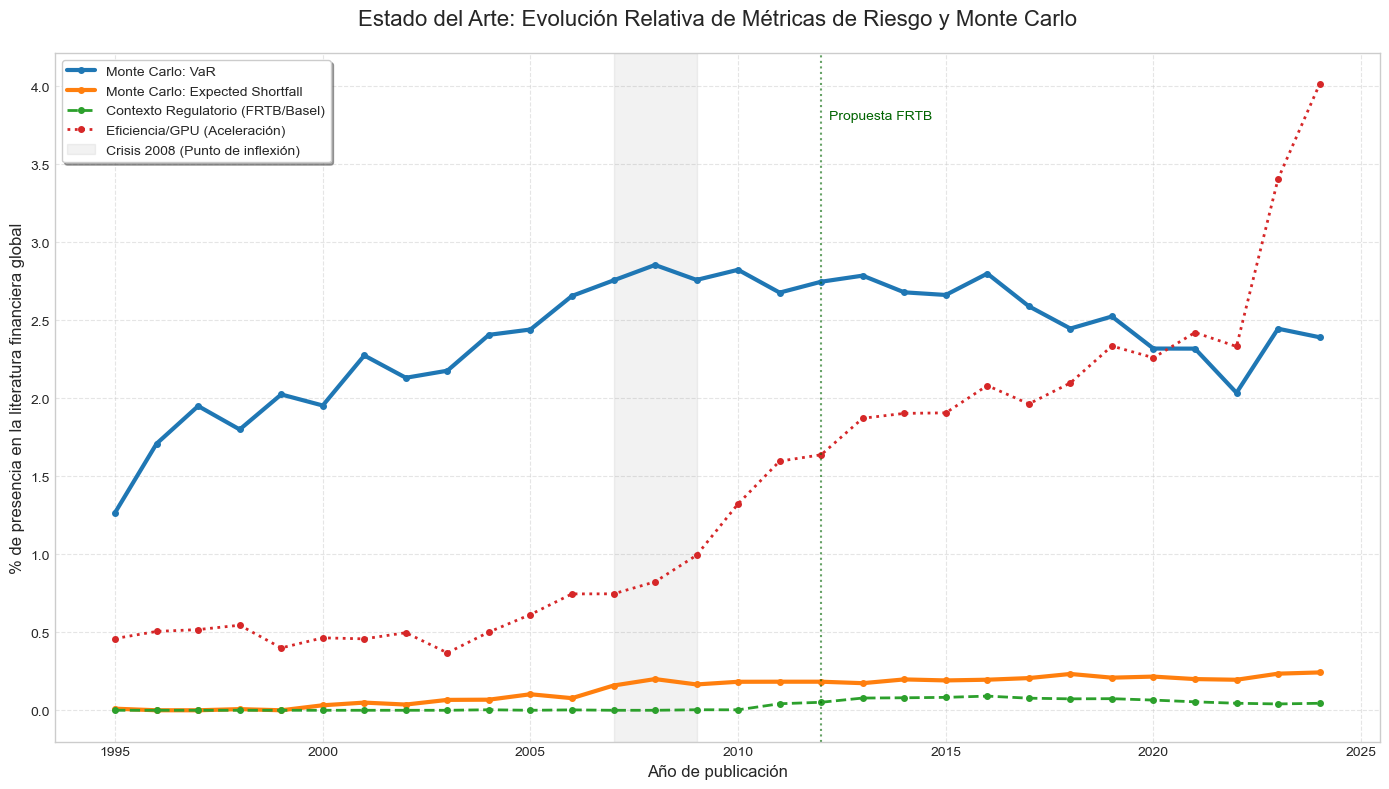

In [37]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import time

def fetch_openalex_counts(query_filter):
    """Obtiene el conteo de publicaciones por año para una consulta específica."""
    base_url = "https://api.openalex.org/works"
    # Filtramos por año y buscamos el término
    params = {
        "search": query_filter,
        "group_by": "publication_year",
        "filter": "publication_year:1990-2025"
    }
    headers = {"User-Agent": "mailto:tu_correo@ejemplo.com"} # Polite pool
    
    try:
        response = requests.get(base_url, params=params, headers=headers)
        if response.status_code == 200:
            data = response.json()
            return {int(g['key']): g['count'] for g in data.get('group_by', [])}
        else:
            print(f"Error en {query_filter}: {response.status_code}")
            return {}
    except Exception as e:
        print(f"Error de conexión: {e}")
        return {}

# 1. DEFINICIÓN DE CATEGORÍAS (Específicas para tu TFM)
# El denominador será el total de investigación en "Finance" para normalizar
categorias = {
    "Baseline (Total Finance)": '"Finance"',
    "Monte Carlo: VaR": '("Monte Carlo") AND ("Value at Risk" OR "VaR")',
    "Monte Carlo: Expected Shortfall": '("Monte Carlo") AND ("Expected Shortfall" OR "CVaR" OR "Conditional Value at Risk")',
    "Contexto Regulatorio (FRTB/Basel)": '("Monte Carlo") AND ("FRTB" OR "Basel III" OR "Fundamental Review of the Trading Book")',
    "Eficiencia/GPU (Aceleración)": '("Monte Carlo") AND ("GPU" OR "CUDA" OR "AAD" OR "Computational Efficiency")'
}

# 2. EJECUCIÓN DE LA EXTRACCIÓN
resultados_absolutos = {}
print("Extrayendo datos de OpenAlex...")

for nombre, query in categorias.items():
    print(f"Consultando: {nombre}")
    resultados_absolutos[nombre] = fetch_openalex_counts(query)
    time.sleep(1) # Respeto a la API

# 3. PROCESAMIENTO Y NORMALIZACIÓN
años = range(1995, 2025) # Rango óptimo para ver la evolución moderna
df_relativo = pd.DataFrame(index=años)

# Usamos el baseline para calcular el % de 'cuota de mercado' de cada tema
total_finance = pd.Series(resultados_absolutos["Baseline (Total Finance)"])

for nombre in categorias.keys():
    if nombre == "Baseline (Total Finance)": continue
    
    conteo_tema = pd.Series(resultados_absolutos[nombre])
    # Normalización: (Menciones del tema / Total de papers de Finanzas) * 100
    df_relativo[nombre] = (conteo_tema / total_finance * 100).fillna(0)

# 4. VISUALIZACIÓN PROFESIONAL PARA TFM
plt.figure(figsize=(14, 8))

# Estilos de línea para diferenciar
estilos = {
    "Monte Carlo: VaR": ("#1f77b4", "-", 3),          # Azul sólido
    "Monte Carlo: Expected Shortfall": ("#ff7f0e", "-", 3), # Naranja sólido
    "Contexto Regulatorio (FRTB/Basel)": ("#2ca02c", "--", 2), # Verde discontinuo
    "Eficiencia/GPU (Aceleración)": ("#d62728", ":", 2)    # Rojo punteado
}

for col in df_relativo.columns:
    color, estilo, ancho = estilos[col]
    plt.plot(df_relativo.index, df_relativo[col], label=col, color=color, linestyle=estilo, linewidth=ancho, marker='o', markersize=4)

# HITOS RELEVANTES PARA TU TFM
plt.axvspan(2007, 2009, color='gray', alpha=0.1, label='Crisis 2008 (Punto de inflexión)')
plt.axvline(x=2012, color='darkgreen', linestyle=':', alpha=0.6)
plt.text(2012.2, plt.ylim()[1]*0.9, 'Propuesta FRTB', fontsize=10, color='darkgreen')

plt.title('Estado del Arte: Evolución Relativa de Métricas de Riesgo y Monte Carlo', fontsize=16, pad=20)
plt.ylabel('% de presencia en la literatura financiera global', fontsize=12)
plt.xlabel('Año de publicación', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='upper left', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

In [ ]:
import requests
import pandas as pd
import time

def extraer_datos_openalex(query, year_start=1975, year_end=2025):
    """Extrae el volumen de publicaciones por año de la API de OpenAlex."""
    url = "https://api.openalex.org/works"
    params = {
        "search": query,
        "group_by": "publication_year",
        "filter": f"publication_year:{year_start}-{year_end}"
    }
    # RECUERDA: Pon tu email real aquí
    headers = {"User-Agent": "mailto:tu_correo@ejemplo.com"} 
    
    try:
        response = requests.get(url, params=params, headers=headers)
        if response.status_code == 200:
            data = response.json()
            return {int(item['key']): item['count'] for item in data.get('group_by', [])}
        else:
            print(f"Error consultando '{query}': HTTP {response.status_code}")
            return {}
    except Exception as e:
        print(f"Error de red: {e}")
        return {}

# 1. DEFINICIÓN DE QUERIES
baseline_query = '"Finance" OR "Economics"'
categorias = {
    "Era Analítica y Complejidad": '"Option Pricing" OR "Black-Scholes" OR "Stochastic Volatility"',
    "Nacimiento del Riesgo Global": '"Value at Risk" OR ("VaR" AND "Finance")',
    "Expected Shortfall Post-2008": '"Expected Shortfall" OR "Conditional Value at Risk" OR "CVaR"',
    "Cuello de Botella Computacional": '("Monte Carlo") AND ("Computational efficiency" OR "GPU" OR "Parallel computing" OR "High performance computing")'
}

# 2. EXTRACCIÓN
print("Iniciando descarga de datos (por favor, espera unos segundos)...")
datos_crudos = {}
datos_crudos["Baseline"] = extraer_datos_openalex(baseline_query)
time.sleep(1)

for nombre, query in categorias.items():
    print(f"Descargando: {nombre}...")
    datos_crudos[nombre] = extraer_datos_openalex(query)
    time.sleep(1.5) # Pausa conservadora para cuidar la API

# 3. PROCESAMIENTO Y GUARDADO
años = range(1975, 2025)
df_relativo = pd.DataFrame(index=años)
serie_baseline = pd.Series(datos_crudos["Baseline"])

for nombre in categorias.keys():
    serie_tema = pd.Series(datos_crudos[nombre])
    df_relativo[nombre] = (serie_tema / serie_baseline * 10000).fillna(0)

# Guardamos a CSV
nombre_archivo = 'datos_tfm_estado_arte.csv'
df_relativo.index.name = 'Año'
df_relativo.to_csv(nombre_archivo)
print(f"\n¡Éxito! Datos guardados en '{nombre_archivo}'. Ya no necesitas llamar a la API.")

Datos cargados y actualizados correctamente.
Gráfico exportado correctamente en alta resolución y con fuentes extra grandes.


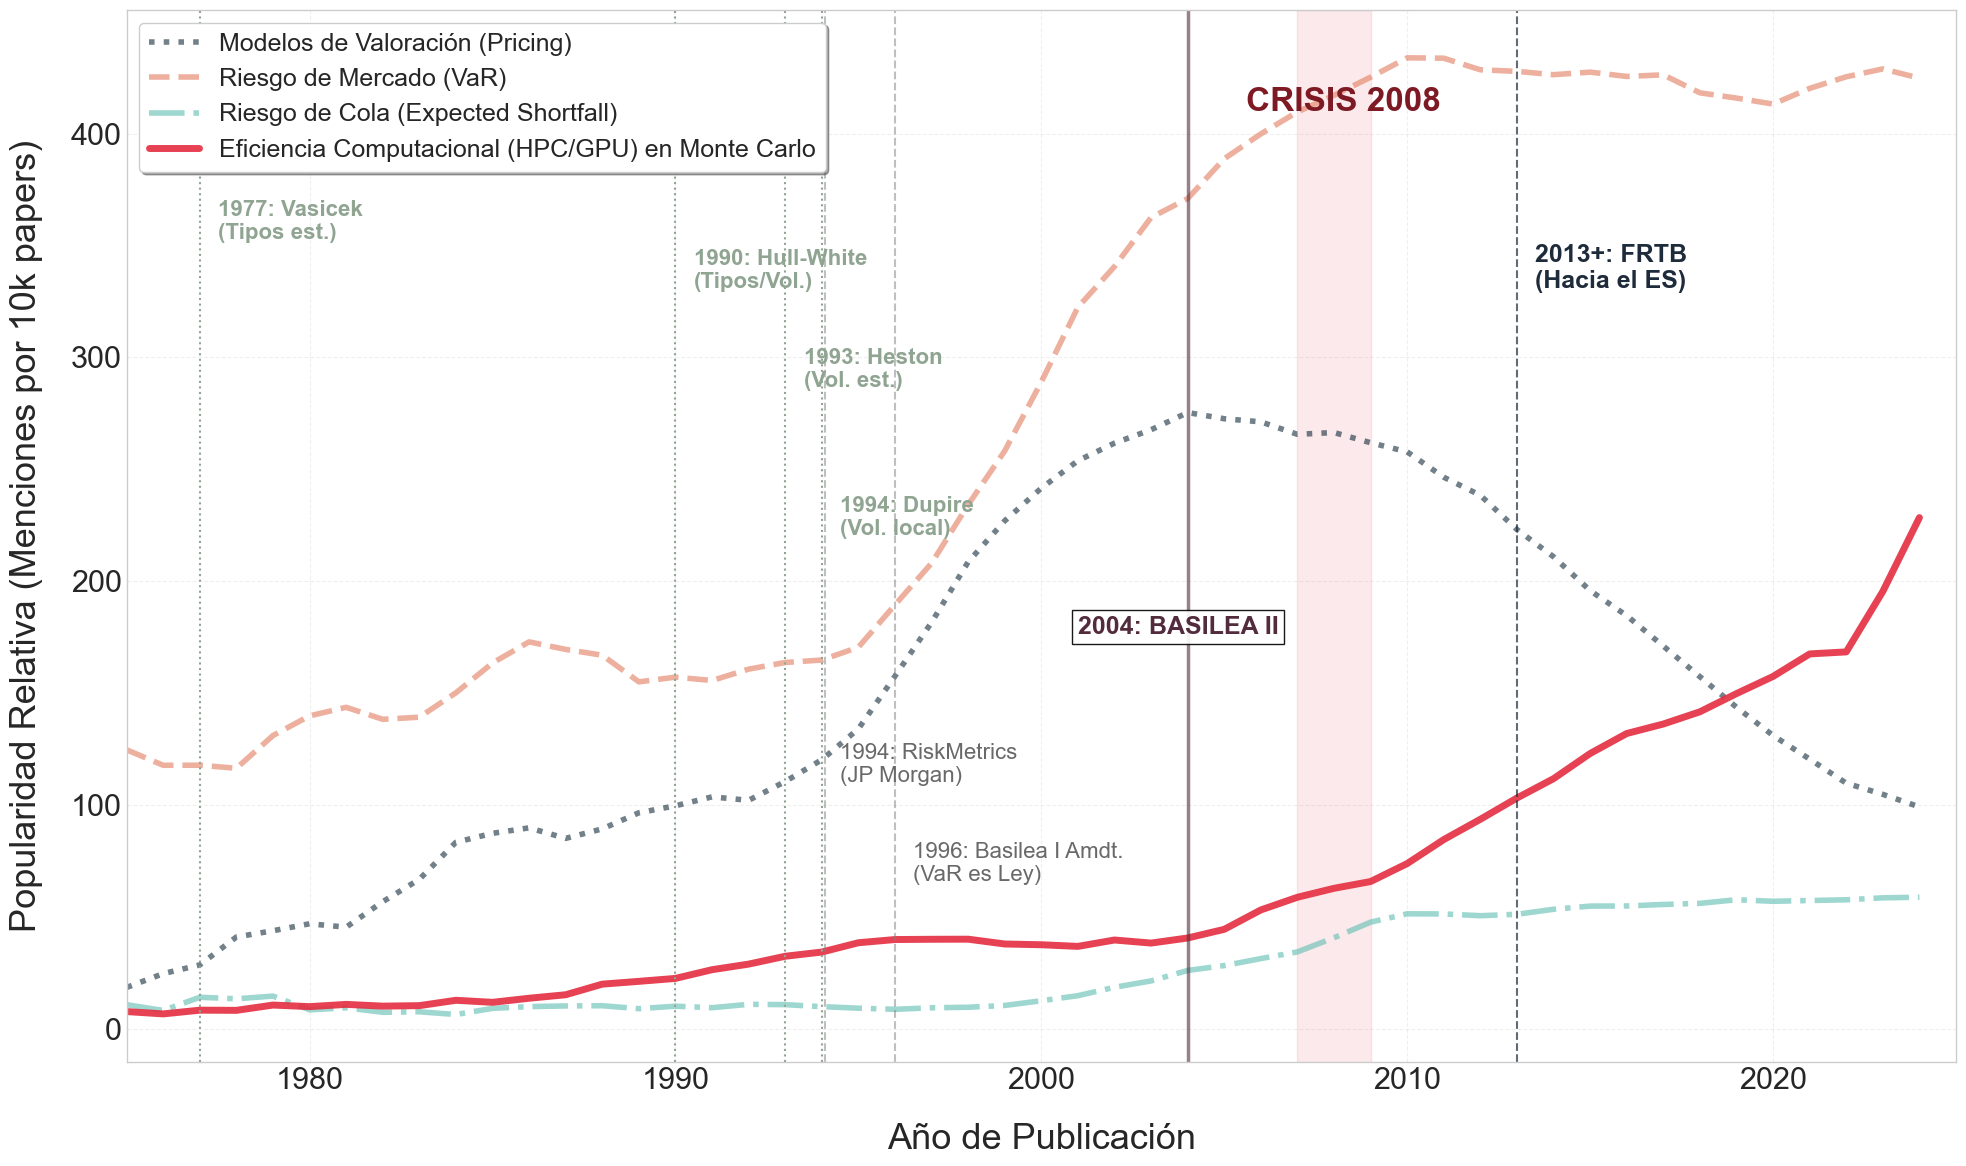

In [70]:
import pandas as pd
import matplotlib.pyplot as plt

# --- CONFIGURACIÓN GLOBAL DE FUENTES (ESCALA GRANDE) ---
# Tamaño base gigante para que todo sea legible al exportar
plt.rcParams.update({'font.size': 18}) 

# 1. CARGA Y RENOMBRADO DE DATOS
try:
    df_relativo = pd.read_csv('datos_tfm_estado_arte.csv', index_col='Año')
    
    nuevos_nombres = {
        "Era Analítica y Complejidad": "Modelos de Valoración (Pricing)",
        "Nacimiento del Riesgo Global": "Riesgo de Mercado (VaR)",
        "Riesgo de Cola Post-2008": "Riesgo de Cola (Expected Shortfall)",
        "Cuello de Botella Computacional": "Eficiencia Computacional (HPC/GPU) en Monte Carlo"
    }
    df_relativo.rename(columns=nuevos_nombres, inplace=True)
    
    print("Datos cargados y actualizados correctamente.")
except FileNotFoundError:
    print("Error: No se encuentra 'datos_tfm_estado_arte.csv'.")
    exit()

# 2. CONFIGURACIÓN VISUAL
# Figura más ancha para acomodar los textos grandes sin solapamientos
fig, ax = plt.subplots(figsize=(20, 12)) 

colores = {
    "Modelos de Valoración (Pricing)": "#142b3b",
    "Riesgo de Mercado (VaR)": "#e47c5d",
    "Riesgo de Cola (Expected Shortfall)": "#5ebdb2",
    "Eficiencia Computacional (HPC/GPU) en Monte Carlo": "#e42d40"
}

estilos = [':', '--', '-.', '-']

# Dibujamos las curvas (líneas ligeramente más gruesas para compensar la fuente)
for i, col in enumerate(df_relativo.columns):
    suavizado = df_relativo[col].rolling(window=3, min_periods=1).mean()
    lw = 5 if i >= 3 else 4  # Líneas más gruesas
    alpha = 0.9 if i >= 3 else 0.6
    ax.plot(suavizado.index, suavizado, label=col, linewidth=lw, 
            linestyle=estilos[i], color=colores.get(col, 'black'), alpha=alpha)

max_y = df_relativo.max().max()

# --- 3. HITOS DE LA HISTORIA (ANOTACIONES EXTRA GRANDES) ---

# A. LA ERA DEL PRICING
anotaciones_pricing = [
    (1977, '1977: Vasicek\n(Tipos est.)'),
    (1990, '1990: Hull-White\n(Tipos/Vol.)'),
    (1993, '1993: Heston\n(Vol. est.)'),
    (1994, '1994: Dupire\n(Vol. local)')
]
for año, texto in anotaciones_pricing:
    ax.axvline(x=año, color='#90a492', linestyle=':', alpha=1)
    offset = 0.80 if año == 1977 else (0.75 if año == 1990 else (0.65 if año == 1993 else 0.50))
    # Fuente a 16pt
    ax.text(año + 0.5, max_y * offset, texto, color='#90a492', fontsize=16, fontweight='bold')

# B. LA ERA DEL RIESGO
ax.axvline(x=1994.1, color='grey', linestyle='--', alpha=0.5)
ax.text(1994.5, max_y * 0.25, '1994: RiskMetrics\n(JP Morgan)', color='dimgrey', fontsize=16)

ax.axvline(x=1996, color='grey', linestyle='--', alpha=0.5)
ax.text(1996.5, max_y * 0.15, '1996: Basilea I Amdt.\n(VaR es Ley)', color='dimgrey', fontsize=16)

# EL GRAN PUNTO DE INFLEXIÓN: 2004
ax.axvline(x=2004, color='#522b3c', linestyle='-', linewidth=2.5, alpha=0.6)
ax.text(2001, max_y * 0.4, '2004: BASILEA II', 
        color="#522b3c", fontsize=18, fontweight='bold', bbox=dict(facecolor='white', alpha=0.9))

# C. CRISIS Y CAMBIO DE PARADIGMA
ax.axvspan(2007, 2009, color="#e42d3f", alpha=0.1)
# Subido a 24pt
ax.text(2005.6, max_y * 0.93, 'CRISIS 2008', color="#7e1a24", fontsize=24, fontweight='bold')

ax.axvline(x=2013, color='#1e2b3b', linestyle='--', alpha=0.7)
ax.text(2013.5, max_y * 0.75, '2013+: FRTB\n(Hacia el ES)', color='#1e2b3b', fontsize=18, fontweight='bold')

# 4. FORMATO ACADÉMICO FINAL
# Etiquetas de los ejes gigantes (22pt)
ax.set_ylabel('Popularidad Relativa (Menciones por 10k papers)', fontsize=26, labelpad=20)
ax.set_xlabel('Año de Publicación', fontsize=26, labelpad=20)
ax.set_xlim(1975, 2025)
ax.grid(True, which='both', linestyle='--', alpha=0.3)

# Números de los ejes (18pt)
ax.tick_params(axis='both', which='major', labelsize=22)

# Leyenda grande (16pt)
ax.legend(loc='upper left', fontsize=18, frameon=True, shadow=True)

# 5. EXPORTAR A PDF
plt.tight_layout()
plt.savefig('evolucion_cuant_tfm.pdf', format='pdf', dpi=300, bbox_inches='tight')

print("Gráfico exportado correctamente en alta resolución y con fuentes extra grandes.")
plt.show()

Datos cargados correctamente.


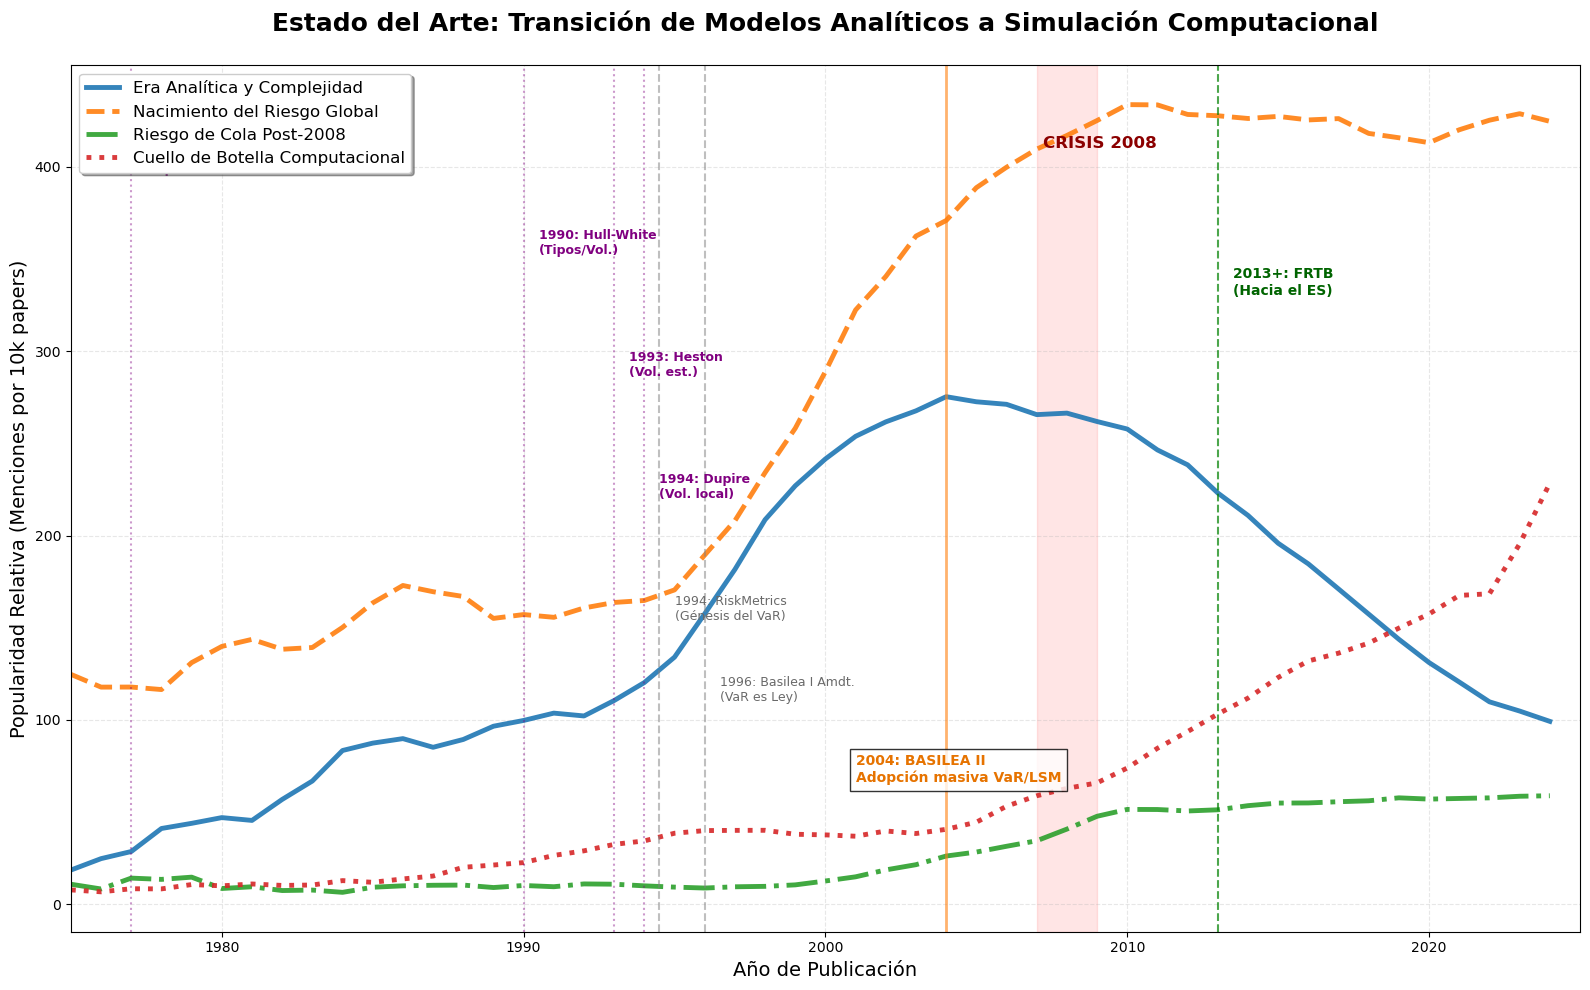

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. CARGA DE DATOS LOCALES
try:
    df_relativo = pd.read_csv('datos_tfm_estado_arte.csv', index_col='Año')
    print("Datos cargados correctamente.")
except FileNotFoundError:
    print("Error: No se encuentra 'datos_tfm_estado_arte.csv'.")
    exit()

# 2. CONFIGURACIÓN VISUAL
fig, ax = plt.subplots(figsize=(16, 10))

# Definimos estilos y colores profesionales
colores = {
    "Era Analítica y Complejidad": "#1f77b4",    # Azul (Pricing)
    "Nacimiento del Riesgo Global": "#ff7f0e",   # Naranja (VaR)
    "Riesgo de Cola Post-2008": "#2ca02c",       # Verde (ES)
    "Cuello de Botella Computacional": "#d62728" # Rojo (Montecarlo/GPU)
}

estilos = ['-', '--', '-.', ':']

# Dibujamos las curvas con suavizado (media móvil de 3 años)
for i, col in enumerate(df_relativo.columns):
    suavizado = df_relativo[col].rolling(window=3, min_periods=1).mean()
    ax.plot(suavizado.index, suavizado, label=col, linewidth=3.5, 
            linestyle=estilos[i], color=colores.get(col, 'black'), alpha=0.9)

# Calculamos el máximo para posicionar etiquetas dinámicamente
max_y = df_relativo.max().max()

# --- 3. HITOS DE LA HISTORIA (ANOTACIONES) ---

# A. LA ERA DEL PRICING (Líneas púrpuras)
anotaciones_pricing = [
    (1977, '1977: Vasicek\n(Tipos est.)'),
    (1990, '1990: Hull-White\n(Tipos/Vol.)'),
    (1993, '1993: Heston\n(Vol. est.)'),
    (1994, '1994: Dupire\n(Vol. local)')
]
for año, texto in anotaciones_pricing:
    ax.axvline(x=año, color='purple', linestyle=':', alpha=0.4)
    # Posicionamiento escalonado para que no se pisen
    offset = 0.90 if año == 1977 else (0.80 if año == 1990 else (0.65 if año == 1993 else 0.50))
    ax.text(año + 0.5, max_y * offset, texto, color='purple', fontsize=9, fontweight='bold')

# B. LA ERA DEL RIESGO (Líneas grises/naranjas)
# JP Morgan / RiskMetrics
ax.axvline(x=1994.5, color='grey', linestyle='--', alpha=0.5)
ax.text(1995, max_y * 0.35, '1994: RiskMetrics\n(Génesis del VaR)', color='dimgrey', fontsize=9)

# Enmienda 1996
ax.axvline(x=1996, color='grey', linestyle='--', alpha=0.5)
ax.text(1996.5, max_y * 0.25, '1996: Basilea I Amdt.\n(VaR es Ley)', color='dimgrey', fontsize=9)

# EL GRAN PUNTO DE INFLEXIÓN: 2004
ax.axvline(x=2004, color='#ff7f0e', linestyle='-', linewidth=2, alpha=0.6)
ax.text(2001, max_y * 0.15, '2004: BASILEA II\nAdopción masiva VaR/LSM', 
        color='#e67300', fontsize=10, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8))

# C. CRISIS Y CAMBIO DE PARADIGMA
# Crisis 2008
ax.axvspan(2007, 2009, color='red', alpha=0.1)
ax.text(2007.2, max_y * 0.93, 'CRISIS 2008', color='darkred', fontsize=12, fontweight='bold')

# FRTB / Expected Shortfall
ax.axvline(x=2013, color='green', linestyle='--', alpha=0.7)
ax.text(2013.5, max_y * 0.75, '2013+: FRTB\n(Hacia el ES)', color='darkgreen', fontsize=10, fontweight='bold')

# 4. FORMATO ACADÉMICO FINAL
ax.set_title('Estado del Arte: Transición de Modelos Analíticos a Simulación Computacional', 
             fontsize=18, pad=25, fontweight='bold')
ax.set_ylabel('Popularidad Relativa (Menciones por 10k papers)', fontsize=14)
ax.set_xlabel('Año de Publicación', fontsize=14)
ax.set_xlim(1975, 2025) # Forzamos el rango para ver a Vasicek
ax.grid(True, which='both', linestyle='--', alpha=0.3)
ax.legend(loc='upper left', fontsize=12, frameon=True, shadow=True)

plt.tight_layout()

# Exportación para el documento
# plt.savefig('evolucion_cuant_tfm.png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. CARGA DE DATOS LOCALES
try:
    df_relativo = pd.read_csv('datos_tfm_estado_arte.csv', index_col='Año')
except FileNotFoundError:
    print("Error: No se encuentra 'datos_tfm_estado_arte.csv'.")
    exit()

# 2. CONFIGURACIÓN VISUAL MODERNA (Estilo limpio)
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(16, 9))

# Paleta de colores elegante y moderna
colores = [
    "#2C3E50", # Azul Marino Oscuro (Pricing)
    "#F39C12", # Ámbar/Dorado (VaR)
    "#16A085", # Verde Esmeralda (ES)
    "#C0392B"  # Rojo Carmesí (Computación/Montecarlo)
]

# Dibujamos las curvas con área sombreada
for i, col in enumerate(df_relativo.columns):
    suavizado = df_relativo[col].rolling(window=3, min_periods=1).mean()
    
    # Línea principal
    ax.plot(suavizado.index, suavizado, label=col, linewidth=3.5, color=colores[i], solid_capstyle='round')
    
    # Área sombreada debajo de la curva
    ax.fill_between(suavizado.index, suavizado, 0, color=colores[i], alpha=0.1)

max_y = df_relativo.max().max()

# --- 3. HITOS DE LA HISTORIA (LÍNEAS VERTICALES INTEGRADAS) ---

# A. Hitos Analíticos (Relacionados con la curva azul marino)
hitos_modelos = [
    (1977, '1977: Vasicek', 0.90),
    (1990, '1990: Hull-White', 0.80),
    (1993, '1993: Heston', 0.65),
    (1994, '1994: Dupire', 0.50)
]
for año, texto, altura in hitos_modelos:
    ax.axvline(x=año, color='#2C3E50', linestyle=':', linewidth=1.5, alpha=0.6)
    ax.text(año + 0.4, max_y * altura, texto, color='#2C3E50', fontsize=10, fontweight='bold')

# B. Hitos de Riesgo/Regulación (Relacionados con la curva ámbar del VaR)
# 1996: Enmienda de Basilea I
ax.axvline(x=1996, color='#F39C12', linestyle='--', linewidth=1.5, alpha=0.8)
ax.text(1996.5, max_y * 0.35, '1996: Basilea I Amdt.\n(El VaR se hace legal)', 
        color='#b0700c', fontsize=10, fontweight='bold')

# 2004: Basilea II (Línea más gruesa para destacar el punto de inflexión)
ax.axvline(x=2004, color='#F39C12', linestyle='-', linewidth=2.5, alpha=0.8)
ax.text(2004.5, max_y * 0.20, '2004: BASILEA II\n(Adopción masiva VaR)', 
        color='#b0700c', fontsize=11, fontweight='bold',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=1))

# C. Crisis y FRTB
# Crisis 2008 (Banda vertical suave)
ax.axvspan(2007, 2009, color='black', alpha=0.08)
ax.text(2008, max_y * 0.95, 'CRISIS 2008', color='black', fontsize=11, fontweight='bold', ha='center', alpha=0.7)

# 2013+: FRTB (Relacionado con la curva verde esmeralda del ES)
ax.axvline(x=2013, color='#16A085', linestyle='--', linewidth=2, alpha=0.8)
ax.text(2013.5, max_y * 0.55, '2013+: FRTB\n(Transición al ES)', 
        color='#0f735f', fontsize=11, fontweight='bold')

# 4. FORMATO ACADÉMICO FINAL
ax.set_title('Evolución del Estado del Arte: De Fórmulas Cerradas a Fuerza Bruta Computacional', 
             fontsize=18, pad=25, fontweight='black', color='#333333')
ax.set_ylabel('Popularidad Relativa (Menciones por 10k papers)', fontsize=12, fontweight='bold', color='#555555')
ax.set_xlabel('Año de Publicación', fontsize=12, fontweight='bold', color='#555555')
ax.set_xlim(1975, 2024)
ax.set_ylim(0, max_y * 1.05) 

# Leyenda limpia
ax.legend(loc='upper left', fontsize=11, frameon=True, facecolor='white', edgecolor='none', shadow=True)

# Quitar bordes innecesarios (Top y Right) para un look más moderno
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

plt.tight_layout()

# Descomenta para guardar
# plt.savefig('figura_estado_arte_moderna_lineas.png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. CARGA DE DATOS LOCALES
try:
    df_relativo = pd.read_csv('datos_tfm_estado_arte.csv', index_col='Año')
except FileNotFoundError:
    print("Error: No se encuentra 'datos_tfm_estado_arte.csv'.")
    exit()

# 2. CONFIGURACIÓN VISUAL MODERNA (Estilo limpio sin sombras)
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(16, 9))

# Paleta de colores elegante y moderna
colores = [
    "#2C3E50", # Azul Marino Oscuro (Pricing)
    "#F39C12", # Ámbar/Dorado (VaR)
    "#16A085", # Verde Esmeralda (ES)
    "#C0392B"  # Rojo Carmesí (Computación/Montecarlo)
]

# Dibujamos las curvas (SIN área sombreada)
for i, col in enumerate(df_relativo.columns):
    suavizado = df_relativo[col].rolling(window=3, min_periods=1).mean()
    
    # Línea principal
    ax.plot(suavizado.index, suavizado, label=col, linewidth=3.5, color=colores[i], solid_capstyle='round')

max_y = df_relativo.max().max()

# --- 3. HITOS DE LA HISTORIA (LÍNEAS VERTICALES INTEGRADAS) ---

# A. Hitos Analíticos (Relacionados con la curva azul marino)
hitos_modelos = [
    (1977, 'Vasicek', 0.90),
    (1990, 'Hull-White', 0.80),
    (1993, 'Heston', 0.65),
    (1994, 'Dupire', 0.50)
]
for año, texto, altura in hitos_modelos:
    ax.axvline(x=año, color='#2C3E50', linestyle=':', linewidth=1.5, alpha=0.6)
    ax.text(año + 0.4, max_y * altura, texto, color='#2C3E50', fontsize=10, fontweight='bold')

# B. Hitos de Riesgo/Regulación (Relacionados con la curva ámbar del VaR)
# Enmienda de Basilea I
ax.axvline(x=1996, color='#F39C12', linestyle='--', linewidth=1.5, alpha=0.8)
ax.text(1996.5, max_y * 0.35, 'Basilea I Amdt.\n(El VaR se hace legal)', 
        color='#b0700c', fontsize=10, fontweight='bold')

# Basilea II (Línea más gruesa para destacar el punto de inflexión)
ax.axvline(x=2004, color='#F39C12', linestyle='-', linewidth=2.5, alpha=0.8)
ax.text(2004.5, max_y * 0.20, 'BASILEA II\n(Adopción masiva VaR)', 
        color='#b0700c', fontsize=11, fontweight='bold',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=1))

# C. Crisis y FRTB
# Crisis 2008 (Banda vertical suave)
ax.axvspan(2007, 2009, color='red', alpha=0.08)
ax.text(2008, max_y * 0.95, 'CRISIS 2008', color='darkred', fontsize=12, fontweight='bold', ha='center', alpha=0.7)

# FRTB (Relacionado con la curva verde esmeralda del ES)
ax.axvline(x=2013, color='#16A085', linestyle='--', linewidth=2, alpha=0.8)
ax.text(2013.5, max_y * 0.55, 'FRTB\n(Transición al ES)', 
        color='#0f735f', fontsize=11, fontweight='bold')

# 4. FORMATO ACADÉMICO FINAL
ax.set_title('Evolución del Estado del Arte: De Fórmulas Cerradas a Fuerza Bruta Computacional', 
             fontsize=18, pad=25, fontweight='black', color='#333333')
ax.set_ylabel('Popularidad Relativa (Menciones por 10k papers)', fontsize=12, fontweight='bold', color='#555555')
ax.set_xlabel('Año de Publicación', fontsize=12, fontweight='bold', color='#555555')
ax.set_xlim(1975, 2024)
ax.set_ylim(0, max_y * 1.05) 

# Leyenda limpia
ax.legend(loc='upper left', fontsize=11, frameon=True, facecolor='white', edgecolor='none', shadow=True)

# Quitar bordes innecesarios (Top y Right) para un look más moderno
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

plt.tight_layout()

# Descomenta para guardar
# plt.savefig('figura_estado_arte_limpia.png', dpi=300, bbox_inches='tight')

plt.show()